In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import os 

In [60]:
chunks = [] 
for chunk in pd.read_csv('bill_schedule.csv',chunksize = 500_000):
    chunk['io_time'] = pd.to_datetime(chunk['io_time']) 
    chunks.append(chunk) 

sche = pd.concat(chunks, ignore_index=True) 
del chunks 
sche = sche.sort_values(['bill_code', 'io_time']).reset_index(drop=True) 


sche['pre_wh'] = sche.groupby('bill_code')['warehouse_name'].shift(1) 
sche_unique = sche[sche['warehouse_name'] != sche['pre_wh']].copy() 
sche_unique['rank'] = sche_unique.groupby('bill_code').cumcount() 


In [61]:
max_rank = sche_unique.groupby('bill_code')['rank'].transform(max) 
sche_unique['rank_re'] = max_rank - sche_unique['rank'] 

C:\Users\VIET ANH\AppData\Local\Temp\ipykernel_18884\1415269964.py:1: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  max_rank = sche_unique.groupby('bill_code')['rank'].transform(max)


In [62]:
wh_1a = pd.read_csv('warehouse_1a.csv') 
set_1a = set(wh_1a['name']) 
sche_1a = sche_unique[sche_unique['warehouse_name'].isin(set_1a)].copy()
count_1a = sche_1a.groupby('bill_code').size().reset_index(name = 'count_1a') 
count_1a = count_1a[count_1a['count_1a'] >= 2] 
sche_unique = sche_unique[sche_unique['bill_code'].isin(set(count_1a['bill_code']))]


In [63]:
traces = pd.read_csv('output_all_traces/bill_trunk_traces.csv')

In [ ]:
traces_1a = traces[traces['bill_code'].isin(set(sche_unique['bill_code']))] 
traces_1a = traces_1a[~traces_1a['first_trunk'].isin(set_1a)] 
traces_1a = traces_1a[~traces_1a['last_trunk'].isin(set_1a)] 
traces_1a.to_csv(os.path.join('output_all_traces', 'traces_1a.csv'), index = False)

In [ ]:
origin = pd.read_csv("output_all_traces/origin_to_1A.csv") 
des = pd.read_csv('output_all_traces/1A_to_destination.csv') 

In [ ]:

print(traces_1a.shape) 
print(origin.shape)
print(des.shape)
print(sche_unique['bill_code'].nunique())

(499915, 7)
(737812, 7)
(673232, 7)
1039840


In [ ]:
sche_final = sche_unique[sche_unique['bill_code'].isin(set(traces_1a['bill_code']))].copy()

In [ ]:
def make_data(sche, title): 
    sche_1a_filter = sche[sche['warehouse_name'].isin(set_1a)]
    first = sche_1a_filter.groupby('bill_code')['rank'].min()
    last = sche_1a_filter.groupby('bill_code')['rank_re'].min()
    rank_first = first.value_counts().sort_index().reset_index()
    rank_last = last.value_counts().sort_index().reset_index()
    rank_first.columns = ['rank_to_1A', 'so_luong_bill']
    rank_last.columns = ['rank_1A_to', 'so_luong_bill']
    print(title)
    print(rank_first)
    print(rank_last)
    print()
    return rank_first, rank_last


through_least_2_first, through_least_2_last = make_data(sche_unique, "through at least two 1A")
traces_least_2_first, traces_least_2_last = make_data(sche_final, "traces well") 


through at least two 1A
   rank_to_1A  so_luong_bill
0           0         309935
1           1         701435
2           2          28300
3           3            158
4           4              8
5           5              2
6           6              2
    rank_1A_to  so_luong_bill
0            0         330194
1            1         643280
2            2          62873
3            3           2461
4            4            848
5            5            116
6            6             45
7            7             12
8            8              8
9            9              1
10          12              2

traces well
   rank_to_1A  so_luong_bill
0           1         480147
1           2          19653
2           3            104
3           4              7
4           5              2
5           6              2
   rank_1A_to  so_luong_bill
0           1         452841
1           2          44615
2           3           1762
3           4            575
4           5          

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6)) 
sns.barplot(data = traces_least_2_last, x="rank_1A_to", y = 'so_luong_bill')
plt.title('Thống kê số lượng Bill theo Rank của Kho 1A đầu tiên (1A -> destination)', fontsize=14, fontweight='bold')
plt.xlabel('Rank của Kho 1A đầu tiên', fontsize=12)
plt.ylabel('Số lượng Bill', fontsize=12)
for index, row in traces_least_2_last.iterrows(): 
    plt.text(index, row['so_luong_bill'], f"{int(row['so_luong_bill']):,}", 
    color = 'black', ha = 'center', va = 'bottom')
plt.tight_layout()
plt.savefig(os.path.join('output_plot', 'rank_to_1A.png'), bbox_inches = 'tight') 
plt.show()

In [ ]:
a = pd.read_csv('output_all_traces/origin_to_1A_filter.csv')


In [ ]:
a = a.sort_values('actual_weight', ascending=False)
print(a[['bill_code', 'actual_weight', 'time_1a_out']][:10])

In [ ]:
df = a.copy() 
df['time_1a_out'] = pd.to_datetime(df['time_1a_out']) 
df['out_15min'] = df['time_1a_out'].dt.floor('15min') 
trip_df = df.groupby(['kho_o1a', 'out_15min']).agg(
    total_bill = ('bill_code', 'nunique'),
    total_weight = ('actual_weight', 'sum'), 
    avg_wait_time = ('time_in_1a', 'mean')
).reset_index() 


trip_df['avg_wait_time'] = trip_df['avg_wait_time'].round(2)
trip_df['total_weight'] = trip_df['total_weight'].round(2)
trip_df['hour_out'] = trip_df['out_15min'].dt.hour + trip_df['out_15min'].dt.minute / 60.0 
trip_df = trip_df.sort_values(['total_weight', 'total_bill'], ascending=[False,False])
print(trip_df.shape)
trip_df.to_csv(os.path.join("output_all_traces", 'trip_1A.csv'), index = False) 

(18895, 6)


In [ ]:
import json 
with open("D:\\optima\\VietAnh\\normal_bill_code_sample.json", 'r', encoding='utf-8') as f:
    data = json.load(f) 

head_data = data.get('head', []) 
tail_data = data.get('tail', []) 
head = pd.DataFrame(data['head'], columns = ['bill_code']) 
tail = pd.DataFrame(data['tail'], columns = ['bill_code'] )

In [ ]:
origin = pd.read_csv('output_all_traces/origin_to_1A.csv') 
des = pd.read_csv('output_all_traces/1A_to_destination.csv')

In [ ]:
print(origin.shape, des.shape)
print(head.shape, tail.shape)

(737812, 7) (673232, 7)
(1050594, 1) (1382029, 1)


In [ ]:
warehouse = pd.read_csv('warehouse.csv') 
set_bc = warehouse[warehouse['Bưu Cục'] == "Y"]['name'].to_list()
print(set_bc)

['Kho Cao Bằng', 'Kho Trung Chuyển Cao Bằng', 'Kho Lạng Sơn', 'Kho Trung Chuyển Lạng Sơn', 'Kho Hạ Long-Quảng Ninh', 'Kho Uông Bí-Quảng Ninh', 'Kho Đông Triều-Quảng Ninh', 'Kho Cẩm Phả-Quảng Ninh', 'Kho Móng Cái-Quảng Ninh', 'Kho Quảng Yên', 'Kho Tổng Quảng Ninh', 'Kho Bưu cục Ngô Quyền', 'Kho An Dương', 'Kho Herbalife Hải Phòng ', 'Kho Kiến An', 'Kho Bưu cục Vĩnh Bảo', 'Kho Thái Bình', 'Kho Hưng Hà ', 'Kho Đông Hưng', 'Kho Tiền Hải', 'Kho Trung Chuyển Thái Bình', 'Kho Nam Định', 'Kho Hải Hậu', 'Kho Trực Ninh', 'Kho Trung Chuyển Nam Định', 'Kho Việt Trì', 'Kho Herbalife Phú Thọ', 'Kho Phú Thọ', 'Kho Bưu Cục Cẩm Khê', 'Kho Trung Chuyển Phú Thọ', 'Kho Thái Nguyên', 'Kho Bưu Cục Phổ Yên', 'Kho Trung Chuyển Thái Nguyên', 'Kho Yên Bái', 'Kho Nghĩa Lộ', 'Kho Bưu cục Nghĩa Lộ', 'Kho Trung Chuyển Yên Bái (Lào Cai)', 'Kho Tuyên Quang', 'Kho Trung Chuyển Tuyên Quang', 'Kho Hà Giang', 'Kho Trung Chuyển Hà Giang - Tuyên Quang', 'Kho Lào Cai', 'Kho Trung Chuyển Lào Cai', 'Kho Lai Châu', 'Kho Trung 

In [ ]:
origin_bc = origin[origin['kho_o'].isin(set_bc)] 
des_bc = des[des['kho_d'].isin(set_bc)] 
print(origin_bc.shape, des_bc.shape)

(429072, 7) (538145, 7)


In [ ]:
oh = origin_bc[origin_bc['bill_code'].isin(set(head['bill_code']))]
ho = head[~head['bill_code'].isin(set(origin_bc['bill_code']))]
dt = des_bc[des_bc['bill_code'].isin(set(tail['bill_code']))] 
td = tail[tail['bill_code'].isin(set(des_bc['bill_code']))]
print(oh.shape, ho.shape) 
print(dt.shape, td.shape)

(419566, 7) (630665, 1)
(517387, 7) (517852, 1)


In [ ]:
oh.to_csv(os.path.join('output_all_traces', 'origin_head.csv'), index = False) 
dt.to_csv(os.path.join('output_all_traces', 'destination_tail.csv'), index = False) 


In [ ]:
print(ho.head(5)) 
print(td.head(5))

   bill_code
2  B_0268006
3  B_0288574
5  B_0312086
6  B_0288315
7  B_0288320
    bill_code
6   B_0760078
7   B_0788055
9   B_0819504
11  B_0773630
12  B_0853534


In [ ]:
combin = origin_bc[origin_bc['bill_code'].isin(set(des_bc['bill_code']))] 
print(combin.shape)

(228845, 7)


In [ ]:
post = pd.read_csv('post_office.csv') 
oh = pd.read_csv('output_all_traces/origin_head.csv') 
dt = pd.read_csv('output_all_traces/destination_tail.csv')

In [ ]:
warehouse = pd.read_csv('warehouse.csv') 
set_bc = warehouse[warehouse['Bưu Cục'] == "Y"]
print(set_bc)

In [ ]:
oh_post = oh[oh['kho_o'].isin(set(post['name']))] 
df_post = dt[dt['kho_d'].isin(set(post['name']))] 
print(oh_post.shape) 
print(dt.shape)

(9410, 7)
(517387, 7)


In [ ]:
warehouse = pd.read_csv('warehouse.csv')

In [ ]:
bc = post[post['name'].isin(set(warehouse['name']))]
print(bc.shape)

(14, 1)


Check bưu cục 






In [13]:
def build_data(df, col_a, col_b, origin): 
    df = df.copy() 
    df['pair'] = df[col_a].astype(str) + '->' + df[col_b].astype(str) 
    check_col = col_b if origin == False else col_a 
    agg = (df.groupby(['pair', check_col])
            .agg(
                so_bill = ('bill_code', 'nunique'), 
                tong_kg = ('actual_weight', 'sum')
            ).reset_index() )
    top = agg.nlargest(30, 'so_bill')
    result = top[check_col].to_list() 
    return result 


In [14]:
df_schedule = pd.read_csv('bill_schedule.csv', usecols=['bill_code', 'io_time', 'warehouse_name'])
df_bill = pd.read_csv('bill.csv', usecols=['bill_code', 'VD_type'])
post = pd.read_csv('post_office.csv') 
oh = pd.read_csv('output_all_traces/origin_head.csv') 
dt = pd.read_csv('output_all_traces/destination_tail.csv')

In [ ]:
sche = df_schedule.copy() 

In [16]:
oh_list = build_data(oh, 'kho_o', 'kho_o1a', True) 
print(oh_list)

['Kho Digiworld', 'Kho Thường Tín', 'Kho Thanh Xuân', 'Kho Amway', 'Kho Bưu Cục Trần Khát Chân', 'Kho Bưu Cục Quận 9', 'Kho Trần Khánh Dư', 'Kho Cầu Giấy', 'Kho BC Hoàng Mai', 'Kho Hà Huy Tập', 'Kho Trung Văn', 'Kho Yên Nghĩa', 'Kho Tây Sơn', 'Kho Long Biên', 'Kho Bưu Cục Quận 7', 'Kho Bưu Cục Cô Giang', 'Kho Bưu Cục Quận 2', 'Kho Bưu cục Ngô Quyền', 'Bưu Cục 82 Chương Dương', 'Kho Thanh Oai', 'Kho La Phù - Hà Nội', 'Kho Nguyễn Văn Cừ', 'Kho Hải Dương', 'Kho Thái Bình', 'Kho Bưu cục Thanh Sơn', 'Kho Bắc Từ Liêm', 'Kho BC Ngọc Hồi', 'Kho Hà Tĩnh', 'Kho Buu cục Quận 3', 'Kho BC Dĩ An']


In [ ]:

df_schedule['io_time'] = pd.to_datetime(df_schedule['io_time'])
df_schedule = df_schedule.sort_values(by=['bill_code', 'io_time'])

first_warehouses = df_schedule.groupby('bill_code').first().reset_index()

target_warehouses = oh_list

filtered_bills = first_warehouses[first_warehouses['warehouse_name'].isin(target_warehouses)]

df_bill['VD_type'] = df_bill['VD_type'].astype(str).str.strip().str.upper()

merged_df = pd.merge(filtered_bills, df_bill, on='bill_code', how='inner')

results = []

for warehouse_name, group in merged_df.groupby('warehouse_name'):
    total_bills = len(group)
    
    if total_bills == 0:
        continue
    web_online_count = (group['VD_type'] == 'BILLWEBONLINE').sum()
    
    percentage = (web_online_count / total_bills) * 100

    # is_passed = percentage > x_percent
    
    print(f"Kho: {warehouse_name}")
    print(f"  - Tổng số bill: {total_bills}")
    print(f"  - Số bill BILLWEBONLINE: {web_online_count}")
    print(f"  - Tỉ lệ: {percentage:.2f}%")
    
    results.append({
        'warehouse_name': warehouse_name,
        'total_bills': total_bills,
        'web_online_bills': web_online_count,
        'percentage': percentage
    })



In [22]:
ans = [] 
for item in results:
    if item['percentage'] >= 85:
        ans.append(item) 
print(ans)

[{'warehouse_name': 'Kho Trung Văn', 'total_bills': 20363, 'web_online_bills': np.int64(17396), 'percentage': np.float64(85.42945538476648)}]


In [52]:
def plot_warehouse_vd_type(df, warehouse_name):

    vd_counts = df['VD_type'].value_counts()

    labels = list(vd_counts.index)
    counts = list(vd_counts.values)
    
    target_label = "BillWebOnline"
    
    if target_label in labels:
        idx = labels.index(target_label)
        target_count = counts.pop(idx)
        target_label_val = labels.pop(idx)
        
        labels.insert(0, target_label_val)
        counts.insert(0, target_count)
    else:
        print(f" Không tìm thấy VD_type '{target_label}' trong dữ liệu của {warehouse_name}")
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(labels, counts, color='skyblue', edgecolor='black')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom')
        
    plt.title(f'Thống kê VD_type cho kho đầu tiên là {warehouse_name}')
    plt.xlabel('VD_type')
    plt.ylabel('Số lượng bill')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

check tần suất suất hiện 

In [4]:
chunks = [] 
for chunk in pd.read_csv('bill_schedule.csv',chunksize = 500_000):
    chunk['io_time'] = pd.to_datetime(chunk['io_time']) 
    chunks.append(chunk) 

sche = pd.concat(chunks, ignore_index=True) 

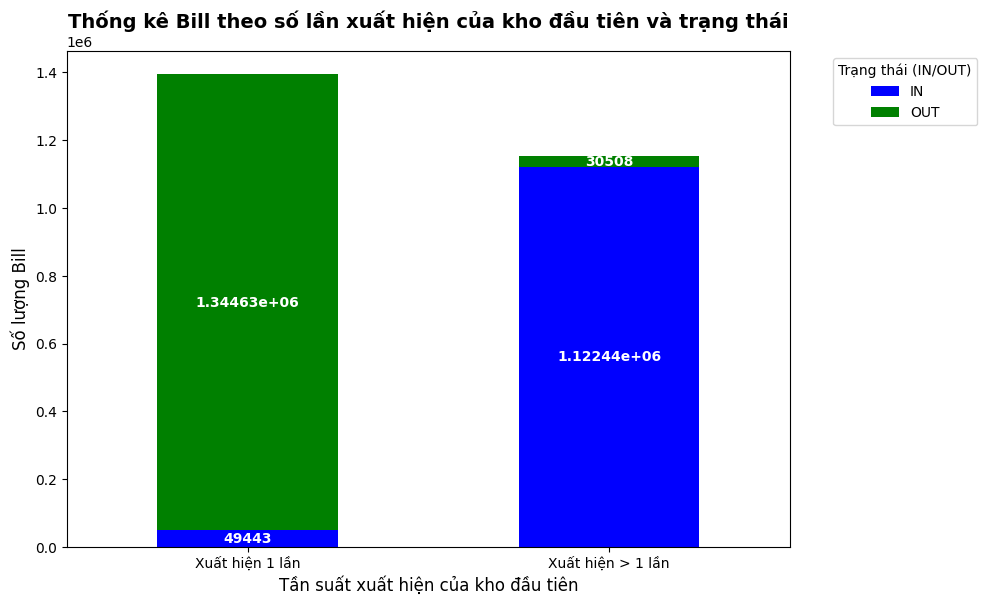

In [12]:

sche = sche.sort_values(['bill_code', 'io_time']).reset_index(drop=True) 
sche['next_wh'] = sche.groupby('bill_code')['warehouse_name'].shift(-1) 
first_rows = sche.groupby('bill_code').first().reset_index() 

first_rows['is_one_time'] = (first_rows['warehouse_name'] != first_rows['next_wh']) 
agg_counts = first_rows.groupby(['is_one_time', 'io_status']).size().unstack(fill_value = 0) 
agg_counts.index = agg_counts.index.map({
    True: 'Xuất hiện 1 lần', 
    False: 'Xuất hiện > 1 lần'
})

agg_counts = agg_counts.reindex(['Xuất hiện 1 lần', 'Xuất hiện > 1 lần']).fillna(0)
ax = agg_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color=['blue', 'green', 'pink'][:len(agg_counts.columns)])
plt.title('Thống kê Bill theo số lần xuất hiện của kho đầu tiên và trạng thái', fontsize=14, fontweight='bold')
plt.xlabel('Tần suất xuất hiện của kho đầu tiên', fontsize=12)
plt.ylabel('Số lượng Bill', fontsize=12)
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, label_type='center', color='white', fontweight='bold')
plt.legend(title='Trạng thái (IN/OUT)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [9]:
print(agg_counts)

io_status               IN      OUT
is_one_time                        
Xuất hiện 1 lần      49443  1344628
Xuất hiện > 1 lần  1122437    30508
